# Heart Disease Prediction — Full ML Pipeline

Binary classification on the `heart.csv` dataset (`HeartDisease` target), comparing
**Logistic Regression**, **Random Forest**, **XGBoost**, and a **Deep Learning (MLP)**
model, then combining them in a **Hybrid Ensemble**.

Sections:
1. Setup
2. Load Data & EDA
3. Train/Test Split & Preprocessing
4. Logistic Regression
5. Random Forest (tuned)
6. XGBoost (tuned)
7. Deep Learning — MLP
8. Hybrid Ensemble & Model Comparison


## 1. Setup

In [1]:
!pip install -q xgboost

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
    cross_validate, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Load Data & EDA

In [3]:
df = pd.read_csv("/content/heart.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

print("\nTarget distribution:")
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True))

Dataset shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -----------

## 3. Train/Test Split & Preprocessing

Two preprocessing pipelines are defined once and reused across every model below:
- `preprocessor_scaled` (StandardScaler + OneHotEncoder) for scale-sensitive models — Logistic Regression, Deep Learning.
- `preprocessor_tree` (OneHotEncoder + passthrough) for tree-based models — Random Forest, XGBoost.

In [4]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("\nTraining shape:", X_train.shape)
print("Testing shape :", X_test.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Training shape: (734, 11)
Testing shape : (184, 11)


In [5]:
# Scale-sensitive models (Logistic Regression, Deep Learning)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
    ]
)

# Tree-based models (Random Forest, XGBoost) - scaling not needed
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

## 4. Logistic Regression

Compare solvers via cross-validation, then keep the best one (by CV F1).

In [6]:
solvers = ["liblinear", "lbfgs", "sag", "newton-cg", "saga"]

lr_results = []

for solver in solvers:
    print("\n" + "=" * 60)
    print(f"Testing Solver: {solver}")
    print("=" * 60)

    log_reg = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver=solver,
        random_state=RANDOM_STATE
    )

    lr_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor_scaled),
        ("logistic_regression", log_reg)
    ])

    cv_scores = cross_validate(
        lr_pipeline, X_train, y_train, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    mean_accuracy = cv_scores["test_accuracy"].mean()
    mean_precision = cv_scores["test_precision"].mean()
    mean_recall = cv_scores["test_recall"].mean()
    mean_f1 = cv_scores["test_f1"].mean()
    mean_roc_auc = cv_scores["test_roc_auc"].mean()

    print(f"CV Accuracy : {mean_accuracy:.4f}")
    print(f"CV Precision: {mean_precision:.4f}")
    print(f"CV Recall   : {mean_recall:.4f}")
    print(f"CV F1       : {mean_f1:.4f}")
    print(f"CV ROC-AUC  : {mean_roc_auc:.4f}")

    lr_results.append({
        "Solver": solver,
        "Pipeline": lr_pipeline,
        "CV Accuracy": mean_accuracy,
        "CV Precision": mean_precision,
        "CV Recall": mean_recall,
        "CV F1": mean_f1,
        "CV ROC-AUC": mean_roc_auc
    })

lr_results_df = pd.DataFrame(lr_results).drop(columns="Pipeline")
lr_results_df = lr_results_df.sort_values(by="CV F1", ascending=False)

print("\n\nSolver Comparison (sorted by CV F1):")
print(lr_results_df.to_string(index=False))


Testing Solver: liblinear
CV Accuracy : 0.8420
CV Precision: 0.8631
CV Recall   : 0.8523
CV F1       : 0.8569
CV ROC-AUC  : 0.9251

Testing Solver: lbfgs
CV Accuracy : 0.8420
CV Precision: 0.8631
CV Recall   : 0.8523
CV F1       : 0.8569
CV ROC-AUC  : 0.9250

Testing Solver: sag
CV Accuracy : 0.8420
CV Precision: 0.8631
CV Recall   : 0.8523
CV F1       : 0.8569
CV ROC-AUC  : 0.9250

Testing Solver: newton-cg
CV Accuracy : 0.8420
CV Precision: 0.8631
CV Recall   : 0.8523
CV F1       : 0.8569
CV ROC-AUC  : 0.9250

Testing Solver: saga
CV Accuracy : 0.8420
CV Precision: 0.8631
CV Recall   : 0.8523
CV F1       : 0.8569
CV ROC-AUC  : 0.9250


Solver Comparison (sorted by CV F1):
   Solver  CV Accuracy  CV Precision  CV Recall    CV F1  CV ROC-AUC
liblinear     0.842009      0.863111   0.852273 0.856897    0.925053
    lbfgs     0.842009      0.863111   0.852273 0.856897    0.924979
      sag     0.842009      0.863111   0.852273 0.856897    0.924979
newton-cg     0.842009      0.863111   0

Creating learning curve for: liblinear


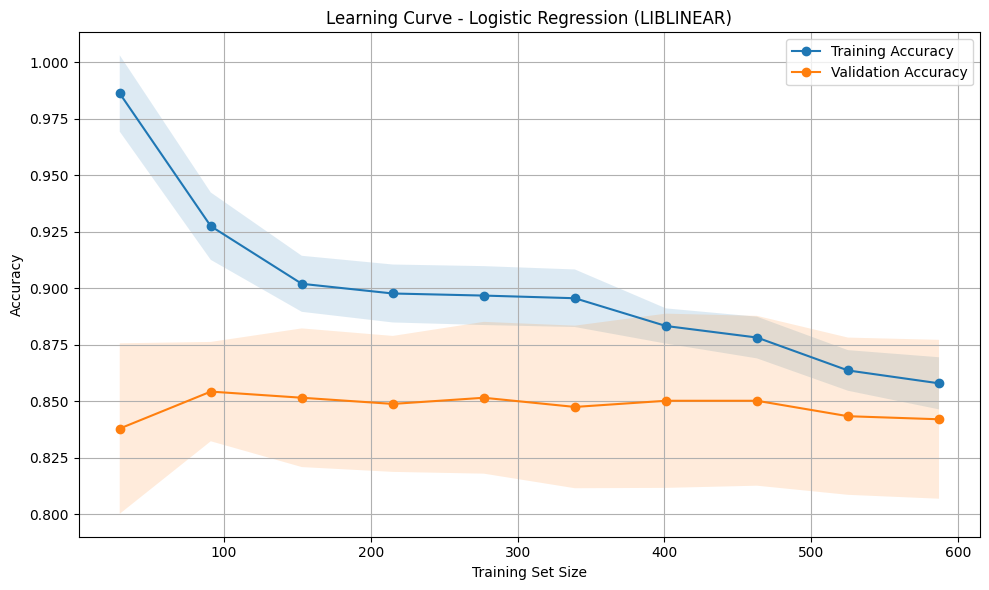

Creating learning curve for: lbfgs


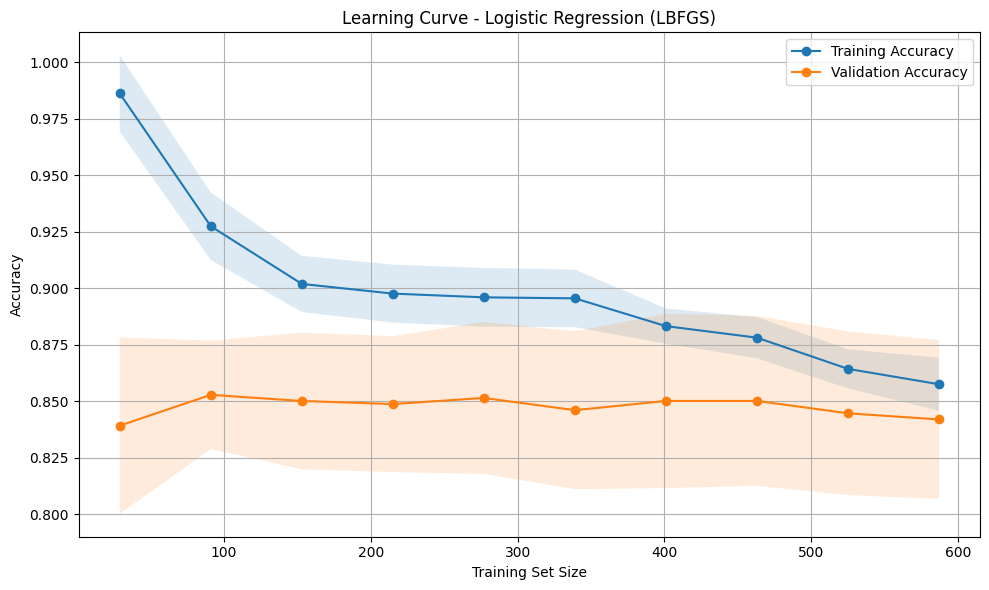

Creating learning curve for: sag


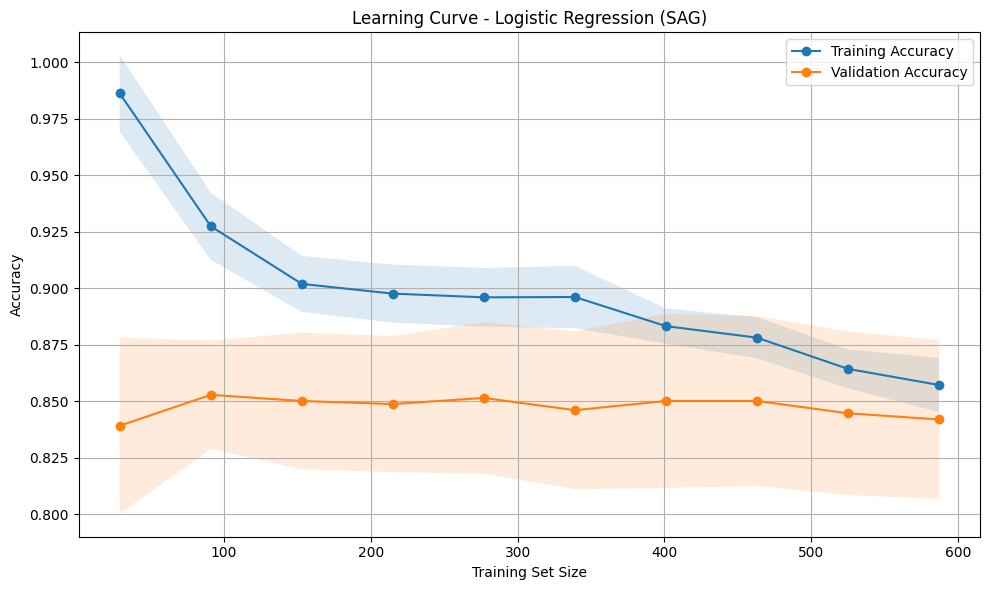

Creating learning curve for: newton-cg


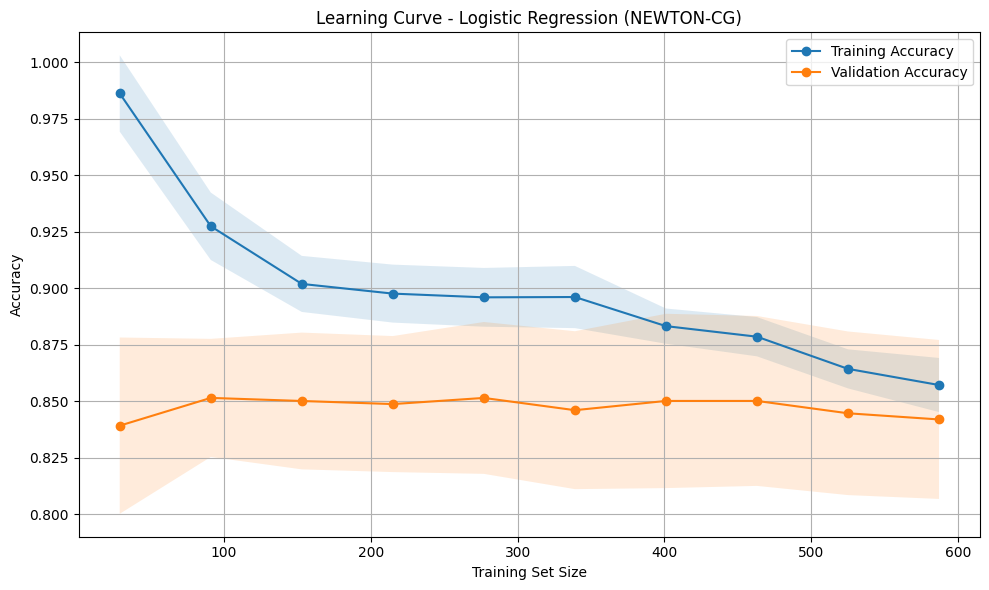

Creating learning curve for: saga


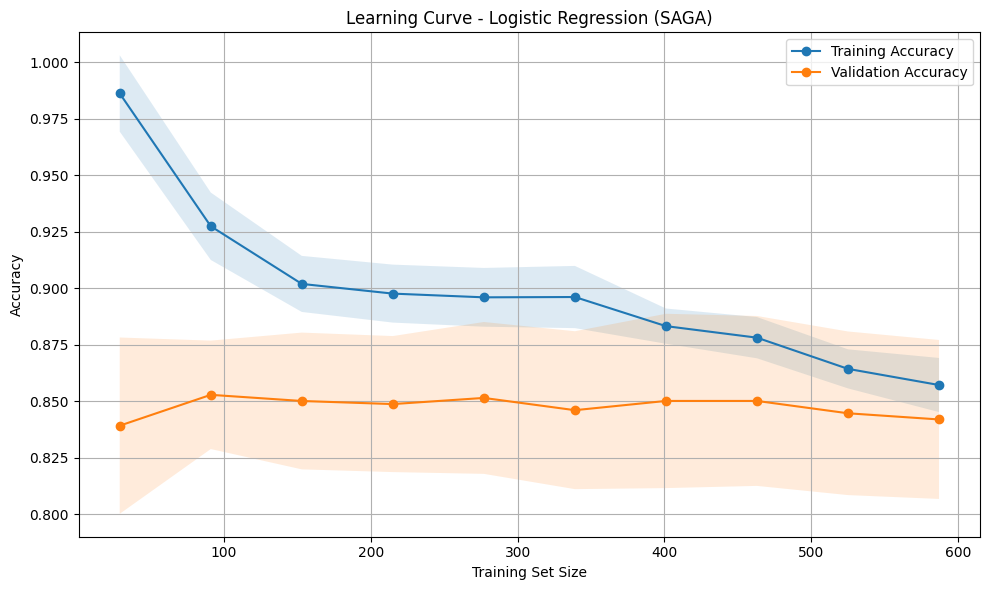

In [7]:
# Learning curves for each solver
for solver in solvers:
    print(f"Creating learning curve for: {solver}")

    log_reg = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver=solver,
        random_state=RANDOM_STATE
    )

    lr_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor_scaled),
        ("logistic_regression", log_reg)
    ])

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=lr_pipeline, X=X_train, y=y_train, cv=cv,
        scoring="accuracy", train_sizes=np.linspace(0.05, 1.0, 10), n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation Accuracy")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.15)
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curve - Logistic Regression ({solver.upper()})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
best_lr_row = max(lr_results, key=lambda r: r["CV F1"])
best_solver = best_lr_row["Solver"]

print(f"Best Logistic Regression solver (by CV F1): {best_solver}")

logistic_model = best_lr_row["Pipeline"]
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression - Test Results")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, logistic_pred):.4f}")
print(f"Precision: {precision_score(y_test, logistic_pred):.4f}")
print(f"Recall   : {recall_score(y_test, logistic_pred):.4f}")
print(f"F1       : {f1_score(y_test, logistic_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, logistic_prob):.4f}")

Best Logistic Regression solver (by CV F1): liblinear

Logistic Regression - Test Results
----------------------------------------
Accuracy : 0.8967
Precision: 0.8879
Recall   : 0.9314
F1       : 0.9091
ROC-AUC  : 0.9296


## 5. Random Forest (Tuned)

Randomized hyperparameter search, then evaluation, learning curve, and feature importance.

In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor_tree),
    ("random_forest", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_grid = {
    "random_forest__n_estimators": [100, 200, 300, 500, 700, 1000],
    "random_forest__max_depth": [5, 8, 10, 12, 15, 20, 25, 30, None],
    "random_forest__min_samples_split": [2, 5, 10, 15, 20],
    "random_forest__min_samples_leaf": [1, 2, 4, 5, 10, 20],
    "random_forest__max_features": ["sqrt", "log2", None],
    "random_forest__criterion": ["gini", "entropy", "log_loss"],
    "random_forest__bootstrap": [True, False],
    "random_forest__class_weight": [None, "balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=100,
    scoring="accuracy",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting Random Forest hyperparameter search...")
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("\nBest Random Forest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation Accuracy: {rf_search.best_score_:.4f}")

Starting Random Forest hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Random Forest parameters:
random_forest__n_estimators: 100
random_forest__min_samples_split: 5
random_forest__min_samples_leaf: 10
random_forest__max_features: log2
random_forest__max_depth: None
random_forest__criterion: entropy
random_forest__class_weight: balanced_subsample
random_forest__bootstrap: False

Best Cross-Validation Accuracy: 0.8761


In [10]:
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest - Test Results")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"F1       : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

Random Forest - Test Results
----------------------------------------
Accuracy : 0.8913
Precision: 0.8868
Recall   : 0.9216
F1       : 0.9038
ROC-AUC  : 0.9269


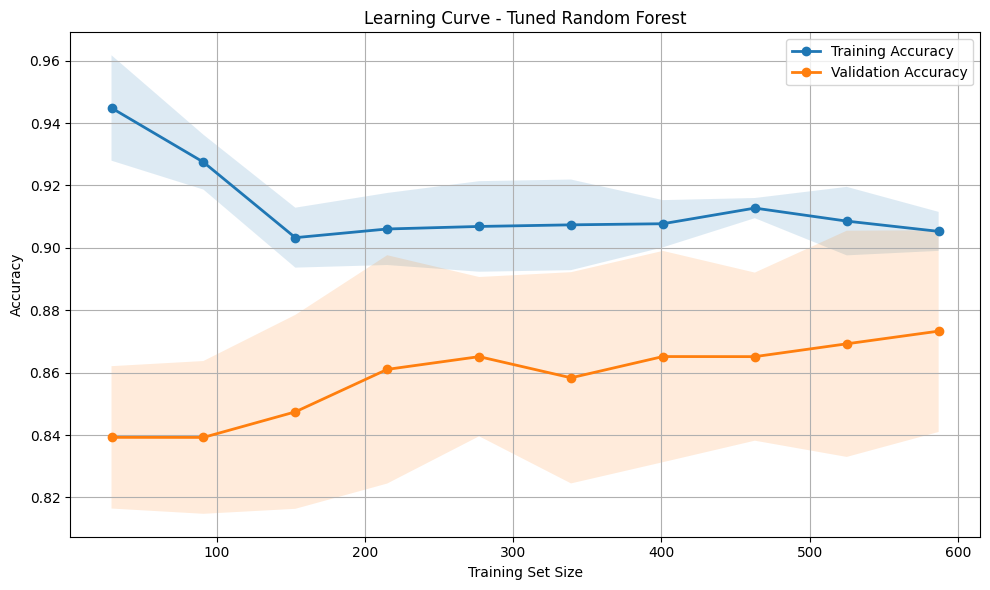

In [11]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_rf, X=X_train, y=y_train, cv=cv,
    scoring="accuracy", train_sizes=np.linspace(0.05, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(train_sizes, validation_mean, marker="o", linewidth=2, label="Validation Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.15)
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Tuned Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

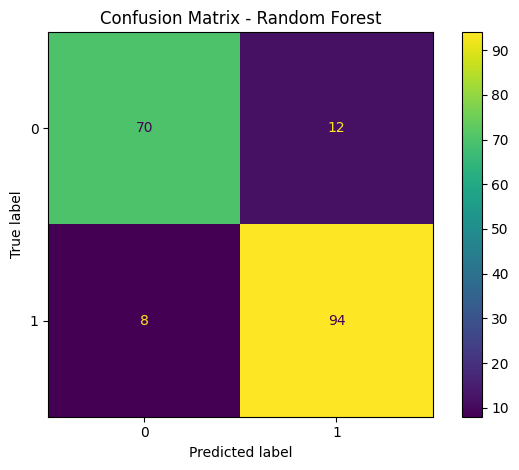

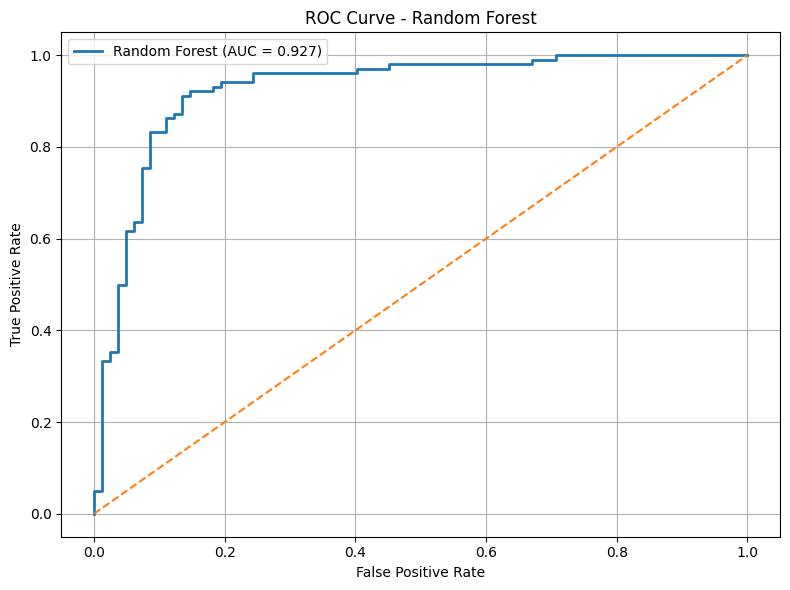

In [12]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Top 15 Feature Importances - Random Forest
                       Feature  Importance
      categorical__ST_Slope_Up    0.214511
    categorical__ST_Slope_Flat    0.144482
categorical__ChestPainType_ASY    0.118443
        remainder__Cholesterol    0.083637
            remainder__Oldpeak    0.078322
 categorical__ExerciseAngina_N    0.066171
 categorical__ExerciseAngina_Y    0.062282
              remainder__MaxHR    0.056275
                remainder__Age    0.031655
          remainder__RestingBP    0.029516
categorical__ChestPainType_ATA    0.024945
            categorical__Sex_F    0.021267
            categorical__Sex_M    0.020412
          remainder__FastingBS    0.014430
categorical__ChestPainType_NAP    0.012481


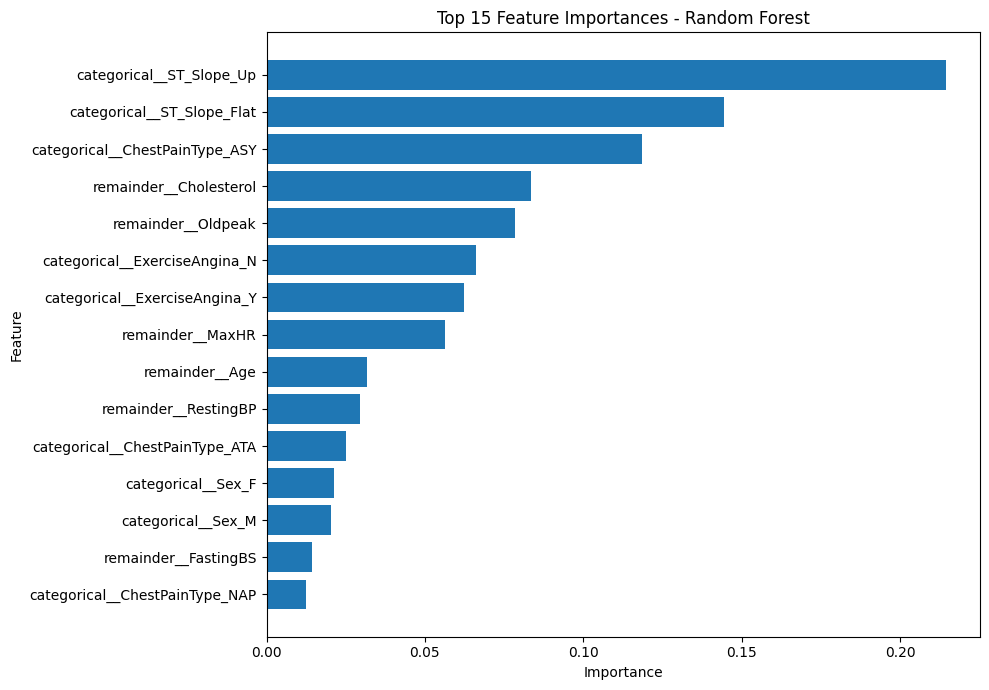

In [13]:
fitted_preprocessor = best_rf.named_steps["preprocessing"]
fitted_rf = best_rf.named_steps["random_forest"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_rf.feature_importances_

rf_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
rf_importance_df = rf_importance_df.sort_values(by="Importance", ascending=False)

print("Top 15 Feature Importances - Random Forest")
print(rf_importance_df.head(15).to_string(index=False))

top_features = rf_importance_df.head(15).sort_values(by="Importance")
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

## 6. XGBoost (Tuned)

Same structure as Random Forest: randomized search, evaluation, learning curve, feature importance.

In [14]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor_tree),
    ("xgboost", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "xgboost__n_estimators": [100, 200, 300, 500, 700, 1000],
    "xgboost__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "xgboost__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2],
    "xgboost__min_child_weight": [1, 2, 3, 5, 7, 10],
    "xgboost__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgboost__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgboost__gamma": [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1],
    "xgboost__reg_alpha": [0, 0.001, 0.01, 0.1, 1],
    "xgboost__reg_lambda": [0.1, 0.5, 1, 2, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=100,
    scoring="accuracy",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting XGBoost hyperparameter search...")
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\nBest XGBoost parameters:")
for parameter, value in xgb_search.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation Accuracy: {xgb_search.best_score_:.4f}")

Starting XGBoost hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best XGBoost parameters:
xgboost__subsample: 0.9
xgboost__reg_lambda: 0.5
xgboost__reg_alpha: 1
xgboost__n_estimators: 700
xgboost__min_child_weight: 3
xgboost__max_depth: 5
xgboost__learning_rate: 0.02
xgboost__gamma: 1
xgboost__colsample_bytree: 0.6

Best Cross-Validation Accuracy: 0.8733


In [15]:
xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost - Test Results")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall   : {recall_score(y_test, xgb_pred):.4f}")
print(f"F1       : {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}")

XGBoost - Test Results
----------------------------------------
Accuracy : 0.8967
Precision: 0.9029
Recall   : 0.9118
F1       : 0.9073
ROC-AUC  : 0.9347


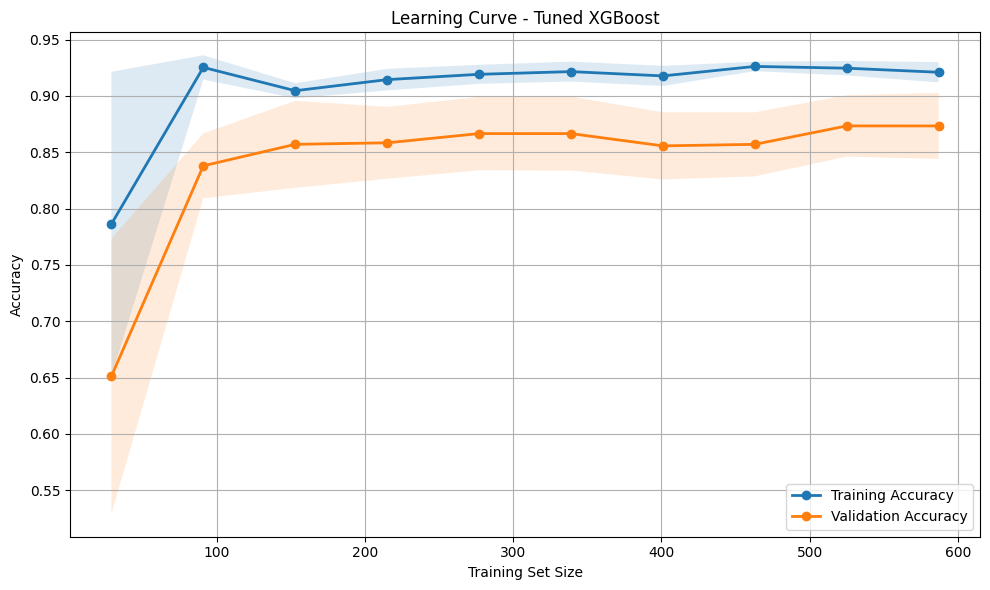

In [16]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_xgb, X=X_train, y=y_train, cv=cv,
    scoring="accuracy", train_sizes=np.linspace(0.05, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(train_sizes, validation_mean, marker="o", linewidth=2, label="Validation Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.15)
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Tuned XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

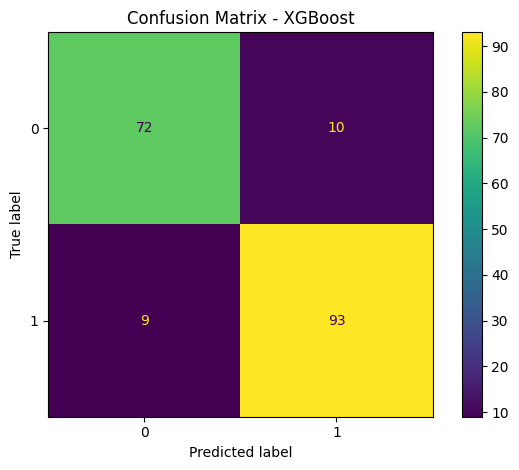

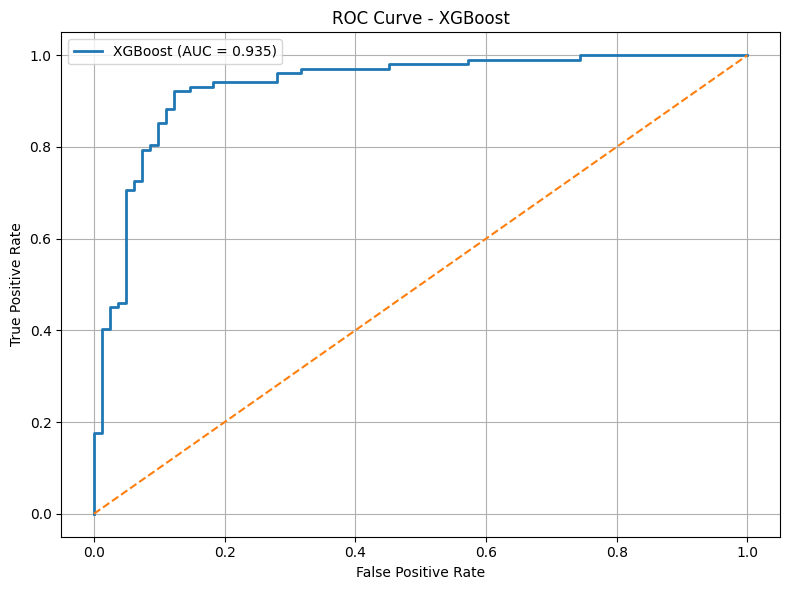

In [17]:
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Top 15 Feature Importances - XGBoost
                       Feature  Importance
      categorical__ST_Slope_Up    0.351672
    categorical__ST_Slope_Flat    0.185731
categorical__ChestPainType_ASY    0.080295
 categorical__ExerciseAngina_N    0.047517
 categorical__ExerciseAngina_Y    0.031983
            remainder__Oldpeak    0.031714
            categorical__Sex_M    0.030248
            categorical__Sex_F    0.028379
          remainder__FastingBS    0.024686
              remainder__MaxHR    0.024196
        remainder__Cholesterol    0.023702
 categorical__ChestPainType_TA    0.023268
   categorical__RestingECG_LVH    0.020430
categorical__ChestPainType_NAP    0.017939
                remainder__Age    0.017018


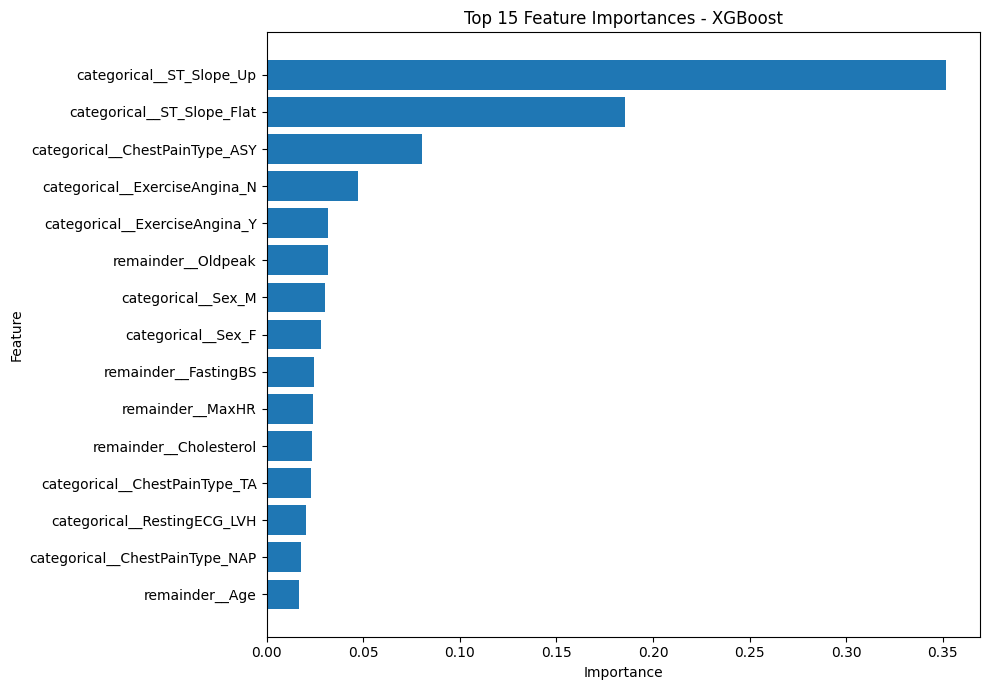

In [18]:
fitted_preprocessor = best_xgb.named_steps["preprocessing"]
fitted_xgb = best_xgb.named_steps["xgboost"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

xgb_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
xgb_importance_df = xgb_importance_df.sort_values(by="Importance", ascending=False)

print("Top 15 Feature Importances - XGBoost")
print(xgb_importance_df.head(15).to_string(index=False))

top_features = xgb_importance_df.head(15).sort_values(by="Importance")
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

## 7. Deep Learning — MLP

Automatic architecture search over several MLP configurations. Models are trained on an
inner train/validation split of `X_train`, ranked by validation accuracy (tie-broken by
lowest overfit gap), and the best one is evaluated on the held-out `X_test`.

In [19]:
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
)

X_train_dl_processed = preprocessor_scaled.fit_transform(X_train_dl).astype("float32")
X_val_dl_processed = preprocessor_scaled.transform(X_val_dl).astype("float32")
X_test_dl_processed = preprocessor_scaled.transform(X_test).astype("float32")

y_train_dl_np = np.asarray(y_train_dl).astype("float32")
y_val_dl_np = np.asarray(y_val_dl).astype("float32")
y_test_dl_np = np.asarray(y_test).astype("float32")

classes = np.unique(y_train_dl_np)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_dl_np)
class_weights = dict(zip(classes, class_weights_array))
print("Class weights:", class_weights)


def build_mlp(input_dim, architecture, dropout, learning_rate):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in architecture:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


mlp_experiments = [
    {"name": "MLP_64_32", "architecture": [64, 32], "dropout": 0.20, "learning_rate": 0.001},
    {"name": "MLP_128_64", "architecture": [128, 64], "dropout": 0.20, "learning_rate": 0.001},
    {"name": "MLP_128_64_Dropout30", "architecture": [128, 64], "dropout": 0.30, "learning_rate": 0.001},
    {"name": "MLP_128_64_32", "architecture": [128, 64, 32], "dropout": 0.20, "learning_rate": 0.001},
    {"name": "MLP_128_64_32_Dropout30", "architecture": [128, 64, 32], "dropout": 0.30, "learning_rate": 0.001},
    {"name": "MLP_128_64_LR0005", "architecture": [128, 64], "dropout": 0.20, "learning_rate": 0.0005},
    {"name": "MLP_256_128_64", "architecture": [256, 128, 64], "dropout": 0.30, "learning_rate": 0.001},
    {"name": "MLP_256_128_64_Dropout40", "architecture": [256, 128, 64], "dropout": 0.40, "learning_rate": 0.0005},
]

Class weights: {np.float32(0.0): np.float64(1.1202290076335877), np.float32(1.0): np.float64(0.9030769230769231)}


In [20]:
mlp_results = []
mlp_histories = {}
mlp_models = {}

for experiment in mlp_experiments:
    print("\n" + "=" * 70)
    print("Training:", experiment["name"])
    print("=" * 70)

    model = build_mlp(
        input_dim=X_train_dl_processed.shape[1],
        architecture=experiment["architecture"],
        dropout=experiment["dropout"],
        learning_rate=experiment["learning_rate"]
    )

    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6, verbose=0)

    history = model.fit(
        X_train_dl_processed, y_train_dl_np,
        validation_data=(X_val_dl_processed, y_val_dl_np),
        epochs=150,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[reduce_lr],
        verbose=0
    )

    best_epoch = np.argmax(history.history["val_accuracy"])
    best_val_accuracy = history.history["val_accuracy"][best_epoch]
    best_train_accuracy = history.history["accuracy"][best_epoch]
    overfit_gap = best_train_accuracy - best_val_accuracy

    val_prob = model.predict(X_val_dl_processed, verbose=0).ravel()
    val_pred = (val_prob >= 0.50).astype(int)

    mlp_results.append({
        "Model": experiment["name"],
        "Architecture": str(experiment["architecture"]),
        "Dropout": experiment["dropout"],
        "Learning Rate": experiment["learning_rate"],
        "Best Epoch": best_epoch + 1,
        "Train Accuracy": best_train_accuracy,
        "Validation Accuracy": best_val_accuracy,
        "Overfit Gap": overfit_gap,
        "Validation F1": f1_score(y_val_dl_np, val_pred),
        "Validation ROC-AUC": roc_auc_score(y_val_dl_np, val_prob)
    })

    mlp_histories[experiment["name"]] = history
    mlp_models[experiment["name"]] = model

mlp_results_df = pd.DataFrame(mlp_results)
mlp_results_df = mlp_results_df.sort_values(by=["Validation Accuracy", "Overfit Gap"], ascending=[False, True])

print("\n\nAll MLP Experiments:")
print(mlp_results_df.to_string(index=False))


Training: MLP_64_32

Training: MLP_128_64

Training: MLP_128_64_Dropout30



Training: MLP_128_64_32

Training: MLP_128_64_32_Dropout30

Training: MLP_128_64_LR0005

Training: MLP_256_128_64

Training: MLP_256_128_64_Dropout40


All MLP Experiments:
                   Model   Architecture  Dropout  Learning Rate  Best Epoch  Train Accuracy  Validation Accuracy  Overfit Gap  Validation F1  Validation ROC-AUC
              MLP_128_64      [128, 64]      0.2         0.0010          23        0.942078             0.884354     0.057725       0.875000            0.911897
               MLP_64_32       [64, 32]      0.2         0.0010          28        0.901192             0.877551     0.023641       0.869565            0.905537
MLP_256_128_64_Dropout40 [256, 128, 64]      0.4         0.0005          43        0.909710             0.870748     0.038962       0.878981            0.912084
          MLP_256_128_64 [256, 128, 64]      0.3         0.0010          18        0.914821             0.870748     0.044073       0.855346            0.895997
       MLP_128_64_LR0

In [21]:
best_mlp_name = mlp_results_df.iloc[0]["Model"]
best_mlp_model = mlp_models[best_mlp_name]
best_mlp_history = mlp_histories[best_mlp_name]

print(f"Best MLP model: {best_mlp_name}")
print(mlp_results_df.iloc[0])

dl_prob = best_mlp_model.predict(X_test_dl_processed, verbose=0).ravel()
dl_pred = (dl_prob >= 0.50).astype(int)

print("\nDeep Learning (MLP) - Test Results")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test_dl_np, dl_pred):.4f}")
print(f"Precision: {precision_score(y_test_dl_np, dl_pred):.4f}")
print(f"Recall   : {recall_score(y_test_dl_np, dl_pred):.4f}")
print(f"F1       : {f1_score(y_test_dl_np, dl_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_dl_np, dl_prob):.4f}")

Best MLP model: MLP_128_64
Model                  MLP_128_64
Architecture            [128, 64]
Dropout                       0.2
Learning Rate               0.001
Best Epoch                     23
Train Accuracy           0.942078
Validation Accuracy      0.884354
Overfit Gap              0.057725
Validation F1               0.875
Validation ROC-AUC       0.911897
Name: 1, dtype: object

Deep Learning (MLP) - Test Results
----------------------------------------
Accuracy : 0.8641
Precision: 0.8889
Recall   : 0.8627
F1       : 0.8756
ROC-AUC  : 0.9346


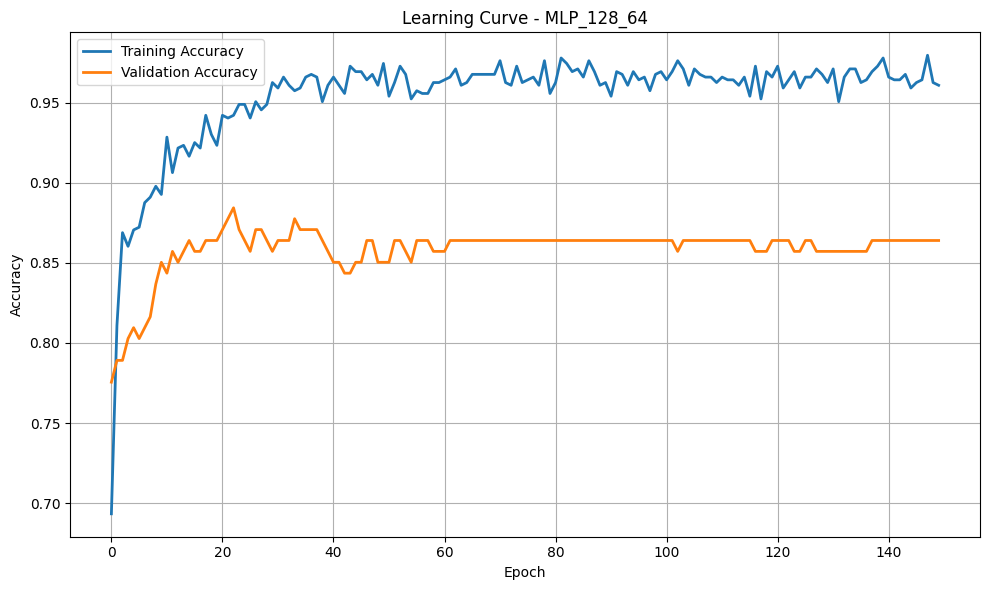

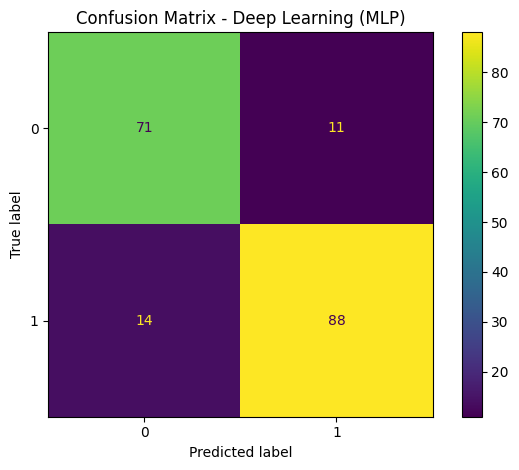

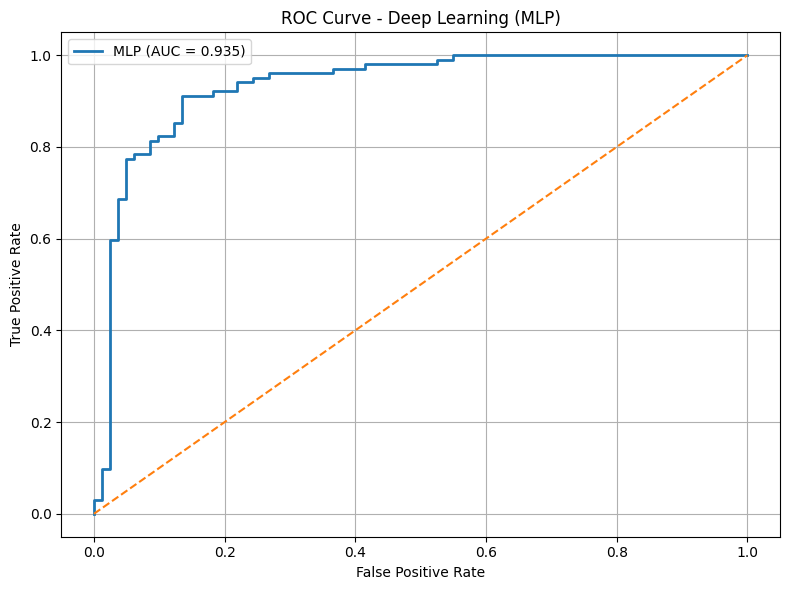

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(best_mlp_history.history["accuracy"], linewidth=2, label="Training Accuracy")
plt.plot(best_mlp_history.history["val_accuracy"], linewidth=2, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve - {best_mlp_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test_dl_np, dl_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Deep Learning (MLP)")
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_dl_np, dl_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"MLP (AUC = {roc_auc_score(y_test_dl_np, dl_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Deep Learning (MLP)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Hybrid Ensemble & Model Comparison

Combines the four tuned models above (`logistic_prob`, `rf_prob`, `xgb_prob`, `dl_prob`)
with fixed weights into a soft-voting ensemble, then compares all five models side by side.

In [23]:
model_probabilities = {
    "Logistic Regression": logistic_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "Deep Learning": dl_prob
}

print("Individual Model Accuracy")
print("=" * 40)
for name, probabilities in model_probabilities.items():
    predictions = (probabilities >= 0.50).astype(int)
    print(f"{name:<25}: {accuracy_score(y_test, predictions):.4f}")

# Ensemble weights (must sum to 1.0).
# XGBoost and Random Forest get slightly higher weight - usually strong on tabular data.
weights = {
    "Logistic Regression": 0.15,
    "Random Forest": 0.25,
    "XGBoost": 0.35,
    "Deep Learning": 0.25
}

assert np.isclose(sum(weights.values()), 1.0), "Ensemble weights must sum to 1."

ensemble_prob = sum(weights[name] * prob for name, prob in model_probabilities.items())
ensemble_pred = (ensemble_prob >= 0.50).astype(int)

ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred)
ensemble_recall = recall_score(y_test, ensemble_pred)
ensemble_f1 = f1_score(y_test, ensemble_pred)
ensemble_auc = roc_auc_score(y_test, ensemble_prob)

print("\nFinal Hybrid Ensemble Results")
print("=" * 40)
print(f"Accuracy : {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall   : {ensemble_recall:.4f}")
print(f"F1 Score : {ensemble_f1:.4f}")
print(f"ROC-AUC  : {ensemble_auc:.4f}")

Individual Model Accuracy
Logistic Regression      : 0.8967
Random Forest            : 0.8913
XGBoost                  : 0.8967
Deep Learning            : 0.8641

Final Hybrid Ensemble Results
Accuracy : 0.9130
Precision: 0.9135
Recall   : 0.9314
F1 Score : 0.9223
ROC-AUC  : 0.9381


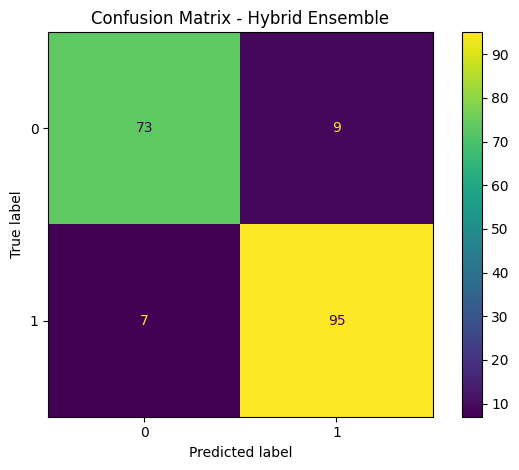

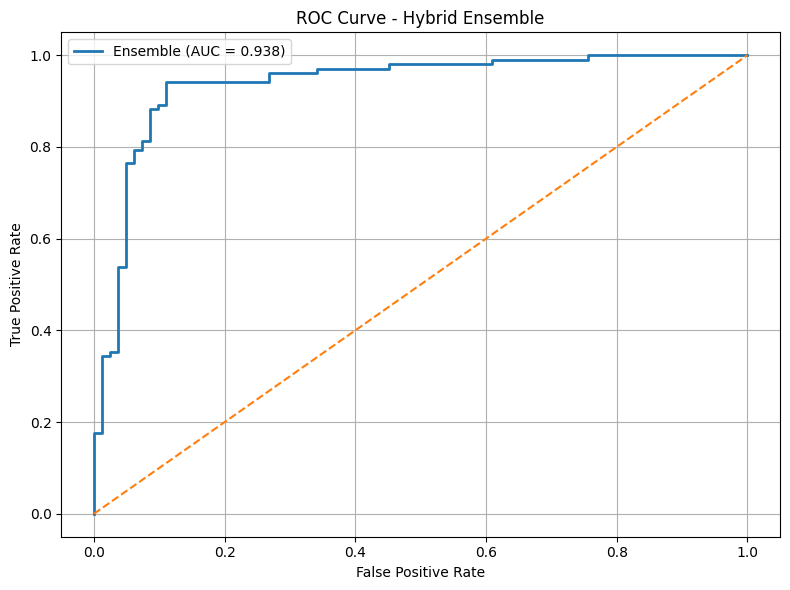

In [24]:
cm = confusion_matrix(y_test, ensemble_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Hybrid Ensemble")
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, ensemble_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Ensemble (AUC = {ensemble_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Ensemble")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Deep Learning", "Hybrid Ensemble"],
    "Accuracy": [
        accuracy_score(y_test, (logistic_prob >= 0.50).astype(int)),
        accuracy_score(y_test, (rf_prob >= 0.50).astype(int)),
        accuracy_score(y_test, (xgb_prob >= 0.50).astype(int)),
        accuracy_score(y_test, (dl_prob >= 0.50).astype(int)),
        ensemble_accuracy
    ],
    "Precision": [
        precision_score(y_test, (logistic_prob >= 0.50).astype(int)),
        precision_score(y_test, (rf_prob >= 0.50).astype(int)),
        precision_score(y_test, (xgb_prob >= 0.50).astype(int)),
        precision_score(y_test, (dl_prob >= 0.50).astype(int)),
        ensemble_precision
    ],
    "Recall": [
        recall_score(y_test, (logistic_prob >= 0.50).astype(int)),
        recall_score(y_test, (rf_prob >= 0.50).astype(int)),
        recall_score(y_test, (xgb_prob >= 0.50).astype(int)),
        recall_score(y_test, (dl_prob >= 0.50).astype(int)),
        ensemble_recall
    ],
    "F1": [
        f1_score(y_test, (logistic_prob >= 0.50).astype(int)),
        f1_score(y_test, (rf_prob >= 0.50).astype(int)),
        f1_score(y_test, (xgb_prob >= 0.50).astype(int)),
        f1_score(y_test, (dl_prob >= 0.50).astype(int)),
        ensemble_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, dl_prob),
        ensemble_auc
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print("Model Comparison")
print("=" * 70)
print(comparison.to_string(index=False))

Model Comparison
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
    Hybrid Ensemble  0.913043   0.913462 0.931373 0.922330 0.938068
Logistic Regression  0.896739   0.887850 0.931373 0.909091 0.929579
            XGBoost  0.896739   0.902913 0.911765 0.907317 0.934720
      Random Forest  0.891304   0.886792 0.921569 0.903846 0.926949
      Deep Learning  0.864130   0.888889 0.862745 0.875622 0.934601


In [26]:
"""
Heart Disease Prediction - Gradio Interface
=============================================
Lets the user enter the 11 feature values of a patient (the same features used in
`heart_disease_pipeline_organized.ipynb`) and choose which trained model to use for
the prediction: Logistic Regression, Random Forest, XGBoost, Deep Learning (MLP),
or the Hybrid Ensemble of all four.

On first launch, all 5 models are trained once from `heart.csv` and cached to disk
(`model_cache/`) so later launches load instantly instead of retraining.

Run:
    python heart_disease_app.py
Requires `heart.csv` (same schema as the notebook) in the same folder.
"""

import os
import warnings

import joblib
import numpy as np
import pandas as pd
import gradio as gr

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH = "heart.csv"
CACHE_DIR = "model_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

TARGET_COL = "HeartDisease"

NUMERICAL_COLUMNS = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
CATEGORICAL_COLUMNS = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
FEATURE_ORDER = [
    "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol",
    "FastingBS", "RestingECG", "MaxHR", "ExerciseAngina", "Oldpeak", "ST_Slope"
]

ENSEMBLE_WEIGHTS = {
    "Logistic Regression": 0.15,
    "Random Forest": 0.25,
    "XGBoost": 0.35,
    "Deep Learning (MLP)": 0.25,
}


# ------------------------------------------------------------------
# Training / caching
# ------------------------------------------------------------------

def _build_preprocessors():
    preprocessor_scaled = ColumnTransformer(
        transformers=[
            ("numerical", StandardScaler(), NUMERICAL_COLUMNS),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLUMNS),
        ]
    )
    preprocessor_tree = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLUMNS),
        ],
        remainder="passthrough",
    )
    return preprocessor_scaled, preprocessor_tree


def _train_all_models():
    df = pd.read_csv(DATA_PATH)

    X = df[FEATURE_ORDER]
    y = df[TARGET_COL]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )

    preprocessor_scaled, preprocessor_tree = _build_preprocessors()

    # --- Logistic Regression ---
    lr_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor_scaled),
        ("logistic_regression", LogisticRegression(
            max_iter=3000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE
        )),
    ])
    lr_pipeline.fit(X_train, y_train)
    lr_test_acc = accuracy_score(y_test, lr_pipeline.predict(X_test))

    # --- Random Forest ---
    rf_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor_tree),
        ("random_forest", RandomForestClassifier(
            n_estimators=500, max_depth=15, min_samples_split=5, min_samples_leaf=2,
            max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        )),
    ])
    rf_pipeline.fit(X_train, y_train)
    rf_test_acc = accuracy_score(y_test, rf_pipeline.predict(X_test))

    # --- XGBoost ---
    xgb_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor_tree),
        ("xgboost", XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, objective="binary:logistic", eval_metric="logloss",
            tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1
        )),
    ])
    xgb_pipeline.fit(X_train, y_train)
    xgb_test_acc = accuracy_score(y_test, xgb_pipeline.predict(X_test))

    # --- Deep Learning (MLP) ---
    dl_preprocessor = ColumnTransformer(
        transformers=[
            ("numerical", StandardScaler(), NUMERICAL_COLUMNS),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLUMNS),
        ]
    )
    X_train_dl = dl_preprocessor.fit_transform(X_train).astype("float32")
    X_test_dl = dl_preprocessor.transform(X_test).astype("float32")
    y_train_dl = np.asarray(y_train).astype("float32")
    y_test_dl = np.asarray(y_test).astype("float32")

    classes = np.unique(y_train_dl)
    class_weights = dict(zip(
        classes, compute_class_weight(class_weight="balanced", classes=classes, y=y_train_dl)
    ))

    mlp_model = Sequential([
        Input(shape=(X_train_dl.shape[1],)),
        Dense(64, activation="relu"), BatchNormalization(), Dropout(0.20),
        Dense(32, activation="relu"), Dropout(0.15),
        Dense(1, activation="sigmoid"),
    ])
    mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    mlp_model.fit(
        X_train_dl, y_train_dl,
        validation_split=0.20, epochs=150, batch_size=32,
        class_weight=class_weights,
        callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
        verbose=0,
    )
    dl_pred = (mlp_model.predict(X_test_dl, verbose=0).ravel() >= 0.50).astype(int)
    dl_test_acc = accuracy_score(y_test_dl, dl_pred)

    # --- Save everything ---
    joblib.dump(lr_pipeline, os.path.join(CACHE_DIR, "logistic_regression.joblib"))
    joblib.dump(rf_pipeline, os.path.join(CACHE_DIR, "random_forest.joblib"))
    joblib.dump(xgb_pipeline, os.path.join(CACHE_DIR, "xgboost.joblib"))
    joblib.dump(dl_preprocessor, os.path.join(CACHE_DIR, "dl_preprocessor.joblib"))
    mlp_model.save(os.path.join(CACHE_DIR, "mlp_model.keras"))

    accuracies = {
        "Logistic Regression": lr_test_acc,
        "Random Forest": rf_test_acc,
        "XGBoost": xgb_test_acc,
        "Deep Learning (MLP)": dl_test_acc,
    }
    joblib.dump(accuracies, os.path.join(CACHE_DIR, "test_accuracies.joblib"))

    return lr_pipeline, rf_pipeline, xgb_pipeline, dl_preprocessor, mlp_model, accuracies


def load_or_train_models():
    paths = [
        os.path.join(CACHE_DIR, "logistic_regression.joblib"),
        os.path.join(CACHE_DIR, "random_forest.joblib"),
        os.path.join(CACHE_DIR, "xgboost.joblib"),
        os.path.join(CACHE_DIR, "dl_preprocessor.joblib"),
        os.path.join(CACHE_DIR, "mlp_model.keras"),
        os.path.join(CACHE_DIR, "test_accuracies.joblib"),
    ]
    if all(os.path.exists(p) for p in paths):
        lr_pipeline = joblib.load(paths[0])
        rf_pipeline = joblib.load(paths[1])
        xgb_pipeline = joblib.load(paths[2])
        dl_preprocessor = joblib.load(paths[3])
        mlp_model = load_model(paths[4])
        accuracies = joblib.load(paths[5])
        return lr_pipeline, rf_pipeline, xgb_pipeline, dl_preprocessor, mlp_model, accuracies

    print("No cached models found - training all 5 models on heart.csv (first run only)...")
    return _train_all_models()


LR_PIPELINE, RF_PIPELINE, XGB_PIPELINE, DL_PREPROCESSOR, MLP_MODEL, TEST_ACCURACIES = load_or_train_models()


# ------------------------------------------------------------------
# Prediction
# ------------------------------------------------------------------

def _sample_to_df(age, sex, chest_pain, resting_bp, cholesterol, fasting_bs,
                   resting_ecg, max_hr, exercise_angina, oldpeak, st_slope):
    row = {
        "Age": age,
        "Sex": sex,
        "ChestPainType": chest_pain,
        "RestingBP": resting_bp,
        "Cholesterol": cholesterol,
        "FastingBS": fasting_bs,
        "RestingECG": resting_ecg,
        "MaxHR": max_hr,
        "ExerciseAngina": exercise_angina,
        "Oldpeak": oldpeak,
        "ST_Slope": st_slope,
    }
    return pd.DataFrame([row], columns=FEATURE_ORDER)


def _predict_with_model(model_name, sample_df):
    if model_name == "Logistic Regression":
        prob = LR_PIPELINE.predict_proba(sample_df)[:, 1][0]
    elif model_name == "Random Forest":
        prob = RF_PIPELINE.predict_proba(sample_df)[:, 1][0]
    elif model_name == "XGBoost":
        prob = XGB_PIPELINE.predict_proba(sample_df)[:, 1][0]
    elif model_name == "Deep Learning (MLP)":
        sample_processed = DL_PREPROCESSOR.transform(sample_df).astype("float32")
        prob = float(MLP_MODEL.predict(sample_processed, verbose=0).ravel()[0])
    elif model_name == "Hybrid Ensemble":
        lr_prob = LR_PIPELINE.predict_proba(sample_df)[:, 1][0]
        rf_prob = RF_PIPELINE.predict_proba(sample_df)[:, 1][0]
        xgb_prob = XGB_PIPELINE.predict_proba(sample_df)[:, 1][0]
        sample_processed = DL_PREPROCESSOR.transform(sample_df).astype("float32")
        dl_prob = float(MLP_MODEL.predict(sample_processed, verbose=0).ravel()[0])
        prob = (
            ENSEMBLE_WEIGHTS["Logistic Regression"] * lr_prob
            + ENSEMBLE_WEIGHTS["Random Forest"] * rf_prob
            + ENSEMBLE_WEIGHTS["XGBoost"] * xgb_prob
            + ENSEMBLE_WEIGHTS["Deep Learning (MLP)"] * dl_prob
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return prob


def predict(model_name, age, sex, chest_pain, resting_bp, cholesterol, fasting_bs,
            resting_ecg, max_hr, exercise_angina, oldpeak, st_slope):

    fasting_bs_value = 1 if fasting_bs == "Yes (> 120 mg/dl)" else 0

    sample_df = _sample_to_df(
        age, sex, chest_pain, resting_bp, cholesterol, fasting_bs_value,
        resting_ecg, max_hr, exercise_angina, oldpeak, st_slope
    )

    prob = _predict_with_model(model_name, sample_df)
    predicted_class = "Heart Disease Detected" if prob >= 0.50 else "No Heart Disease"

    label_output = {
        "Heart Disease Detected": float(prob),
        "No Heart Disease": float(1 - prob),
    }

    if model_name == "Hybrid Ensemble":
        note = "Weighted soft-voting ensemble of all 4 models."
    else:
        acc = TEST_ACCURACIES.get(model_name)
        note = f"Model test-set accuracy: {acc:.2%}" if acc is not None else ""

    summary = (
        f"**Prediction:** {predicted_class}\n\n"
        f"**Probability of Heart Disease:** {prob:.2%}\n\n"
        f"**Model used:** {model_name}\n\n"
        f"{note}"
    )

    return label_output, summary


# ------------------------------------------------------------------
# Interface
# ------------------------------------------------------------------

with gr.Blocks(title="Heart Disease Prediction") as demo:
    gr.Markdown(
        "# Heart Disease Prediction\n"
        "Enter a patient's feature values, pick a model, and get a prediction."
    )

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("### Patient Features")
            with gr.Row():
                age = gr.Slider(minimum=18, maximum=100, value=50, step=1, label="Age")
                sex = gr.Radio(choices=["M", "F"], value="M", label="Sex")
            with gr.Row():
                chest_pain = gr.Dropdown(
                    choices=["ATA", "NAP", "ASY", "TA"], value="ATA",
                    label="Chest Pain Type",
                    info="ATA=Atypical Angina, NAP=Non-Anginal Pain, ASY=Asymptomatic, TA=Typical Angina"
                )
                resting_ecg = gr.Dropdown(
                    choices=["Normal", "ST", "LVH"], value="Normal", label="Resting ECG"
                )
            with gr.Row():
                resting_bp = gr.Slider(minimum=60, maximum=220, value=120, step=1, label="Resting Blood Pressure (mm Hg)")
                cholesterol = gr.Slider(minimum=0, maximum=600, value=200, step=1, label="Cholesterol (mg/dl)")
            with gr.Row():
                fasting_bs = gr.Radio(
                    choices=["No (<= 120 mg/dl)", "Yes (> 120 mg/dl)"],
                    value="No (<= 120 mg/dl)", label="Fasting Blood Sugar"
                )
                max_hr = gr.Slider(minimum=60, maximum=220, value=150, step=1, label="Max Heart Rate Achieved")
            with gr.Row():
                exercise_angina = gr.Radio(choices=["Y", "N"], value="N", label="Exercise-Induced Angina")
                oldpeak = gr.Slider(minimum=-3.0, maximum=7.0, value=0.0, step=0.1, label="Oldpeak (ST Depression)")
            st_slope = gr.Dropdown(choices=["Up", "Flat", "Down"], value="Up", label="ST Slope")

        with gr.Column(scale=1):
            gr.Markdown("### Model & Prediction")
            model_choice = gr.Dropdown(
                choices=[
                    "Logistic Regression",
                    "Random Forest",
                    "XGBoost",
                    "Deep Learning (MLP)",
                    "Hybrid Ensemble",
                ],
                value="Hybrid Ensemble",
                label="Select Model",
            )
            predict_btn = gr.Button("Predict", variant="primary")
            output_label = gr.Label(label="Prediction")
            output_summary = gr.Markdown()

    predict_btn.click(
        fn=predict,
        inputs=[
            model_choice, age, sex, chest_pain, resting_bp, cholesterol,
            fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope,
        ],
        outputs=[output_label, output_summary],
    )

if __name__ == "__main__":
    demo.launch()

No cached models found - training all 5 models on heart.csv (first run only)...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d8d2db46aac415c86.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
